**1. Import Libraries**

In [0]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import torch
import torch.nn as nn
import torch.utils.data as td
import torch.nn.functional as F

**2. Load Data**

In [0]:
# load data to dataframe and display 
df = spark.table('workspace.default.diabetes_data_explored')
display(df.limit(5))

cholesterol_total,stabilized_glucose,hdl_cholesterol,chol_hdl_ratio,location,age,gender,body_frame,systolic_bp_1,diastolic_bp_1,minutes_post_meal,BMI,waist_hip_ratio,hba1c_category
203.0,82.0,56.0,3.6,Buckingham,46,female,medium,118.0,59.0,720,22.130944261888523,0.7631578947368421,Normal
165.0,97.0,24.0,6.9,Buckingham,29,female,large,112.0,68.0,360,37.41920003371257,0.9583333333333334,Normal
228.0,92.0,37.0,6.2,Buckingham,58,female,large,190.0,92.0,180,48.37024068028249,0.8596491228070176,Normal
78.0,93.0,12.0,6.5,Buckingham,67,male,large,110.0,50.0,480,18.637828409539644,0.868421052631579,Normal
249.0,90.0,28.0,8.9,Buckingham,64,male,medium,138.0,80.0,300,27.824746566448155,1.0731707317073171,Diabetic


**3. Encode Categorical Columns**

In [0]:
# Define indexers for each categorical column
indexer_label = StringIndexer(inputCol="hba1c_category", outputCol="label")
indexer_location = StringIndexer(inputCol="location", outputCol="locationIdx")
indexer_gender = StringIndexer(inputCol="gender", outputCol="genderIdx")
indexer_body_frame = StringIndexer(inputCol="body_frame", outputCol="bodyFrameIdx")

# Chain them together in a pipeline
pipeline = Pipeline(stages=[indexer_label, indexer_location, indexer_gender, indexer_body_frame])

# Fit and transform the training data
indexedData = (pipeline.fit(df).transform(df).drop("location", "gender", "body_frame", "minutes_post_meal", "hba1c_category"))

**4. Normalize Numeric Features**

In [0]:
feature_cols = ["cholesterol_total","stabilized_glucose","hdl_cholesterol","chol_hdl_ratio","age","systolic_bp_1","diastolic_bp_1","BMI","waist_hip_ratio"]
df_scaled = indexedData

for col_name in feature_cols:
    # Get min and max values for the column
    stats = (indexedData.select(F.min(col_name).alias("min_val"),F.max(col_name).alias("max_val")).first())

    min_val = stats["min_val"]
    max_val = stats["max_val"]

    # Apply Min-Max scaling
    df_scaled = df_scaled.withColumn(col_name,(F.col(col_name) - F.lit(min_val)) /F.lit(max_val - min_val))

In [0]:
# Oversample the dataframe to increase its size
# Deep learning techniques work well with a lot of data
for i in range(1,3):
   df_scaled = df_scaled.union(df_scaled)

In [0]:
display(df_scaled.count())

1548

**5. Split Data**

In [0]:
# Split the data into training and testing datasets
features = ["cholesterol_total","stabilized_glucose","hdl_cholesterol","chol_hdl_ratio","age","systolic_bp_1","diastolic_bp_1","BMI","waist_hip_ratio", "locationIdx", "genderIdx", "bodyFrameIdx"]
label = 'label'

In [0]:
# Split data 70%-30% into training set and test set
x_train, x_test, y_train, y_test = train_test_split(df_scaled.toPandas()[features].values,
                                                   df_scaled.toPandas()[label].values,
                                                   test_size=0.30,
                                                   random_state=0)

print ('Training Set: %d rows, Test Set: %d rows \n' % (len(x_train), len(x_test)))


Training Set: 1083 rows, Test Set: 465 rows 



In [0]:
# Set random seed for reproducability
torch.manual_seed(0)

print("Libraries imported - ready to use PyTorch", torch.__version__)

Libraries imported - ready to use PyTorch 2.9.0+cu129


**6. Create Data Loaders** <br>
PyTorch makes use of data loaders to load training and validation data in batches. The data has been loaded into numpy arrays, but we need to wrap those in PyTorch datasets where the data is converted to PyTorch tensor objects and create loaders to read batches from those datasets.


In [0]:
# Create a dataset and loader for the training data and labels
train_x = torch.Tensor(x_train).float()
train_y = torch.Tensor(y_train).long()
train_ds = td.TensorDataset(train_x,train_y)
train_loader = td.DataLoader(train_ds, batch_size=20,
   shuffle=False, num_workers=0)

# Create a dataset and loader for the test data and labels
test_x = torch.Tensor(x_test).float()
test_y = torch.Tensor(y_test).long()
test_ds = td.TensorDataset(test_x,test_y)
test_loader = td.DataLoader(test_ds, batch_size=20,
                            shuffle=False, num_workers=0)
print('Ready to load data')

Ready to load data


**7. Define a Neural Network**<br>
Now we define our neural network. We create a network that consists of 3 fully-connected layers:<br>
- An input layer that receives 12 input values and generated 16 outputs.
- A hidden layer that receives 16 inputs from the input layer and sends 16 outputs to the next layer.
- An output layer that generates a vector of probabilities for each of the two possible diabetes category.
<br>

As we train the network by passing data through it, the forward function will apply RELU activation functions to the first two layers (to constrain the results to positive numbers) and return a final output layer that uses a log_softmax function to return a value that represents a probability score for each of the two possible classes.



In [0]:
# Define number of nodes per hidden layer
hl = 16

# Define the neural network
class DiabetesNet(nn.Module):
   def __init__(self):
       super(DiabetesNet, self).__init__()
       self.fc1 = nn.Linear(len(features), hl)
       self.fc2 = nn.Linear(hl, hl)
       self.fc3 = nn.Linear(hl, 2)

   def forward(self, x):
       fc1_output = torch.relu(self.fc1(x))
       fc2_output = torch.relu(self.fc2(fc1_output))
       y = F.log_softmax(self.fc3(fc2_output).float(), dim=1)
       return y

# Create a model instance from the network
model = DiabetesNet()
print(model)

DiabetesNet(
  (fc1): Linear(in_features=12, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)


**8. Create Functions to Train and Test a Neural Network Model** <br>
To train the model, we repeatedly feed the training values forward through the network, use a loss function to calculate the loss, use an optimizer to backpropagate the weight and bias value adjustments, and validate the model using the test data. We create a function to train and optimize the model, and a function to test the model.

In [0]:
def train(model, data_loader, optimizer):
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   model.to(device)
   # Set the model to training mode
   model.train()
   train_loss = 0

   for batch, tensor in enumerate(data_loader):
       data, target = tensor
       data = data.to(device)
       target = target.to(device)
       #feedforward
       optimizer.zero_grad()
       out = model(data)
       loss = loss_criteria(out, target)
       train_loss += loss.item()
       # backpropagate adjustments to the weights
       loss.backward()
       optimizer.step()

   #Return average loss
   avg_loss = train_loss / (batch+1)
   print('Training set: Average loss: {:.6f}'.format(avg_loss))
   return avg_loss

def test(model, data_loader):
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   model.to(device)
   # Switch the model to evaluation mode (so we don't backpropagate)
   model.eval()
   test_loss = 0
   correct = 0

   with torch.no_grad():
       batch_count = 0
       for batch, tensor in enumerate(data_loader):
           batch_count += 1
           data, target = tensor
           data = data.to(device)
           target = target.to(device)
           # Get the predictions
           out = model(data)
           # calculate the loss
           test_loss += loss_criteria(out, target).item()
           # Calculate the accuracy
           _, predicted = torch.max(out.data, 1)
           correct += torch.sum(target==predicted).item()

   # Calculate the average loss and total accuracy for this epoch
   avg_loss = test_loss/batch_count
   print('Validation set: Average loss: {:.6f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
       avg_loss, correct, len(data_loader.dataset),
       100. * correct / len(data_loader.dataset)))

   # return average loss for the epoch
   return avg_loss

**9. Train Model**<br>
Now you can use the train and test functions to train a neural network model. You train neural networks iteratively over multiple epochs, logging the loss and accuracy statistics for each epoch.


In [0]:
# Specify the loss criteria (we'll use CrossEntropyLoss for multi-class classification)
loss_criteria = nn.CrossEntropyLoss()

# Use an optimizer to adjust weights and reduce loss
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer.zero_grad()

# We'll track metrics for each epoch in these arrays
epoch_nums = []
training_loss = []
validation_loss = []

# Train over 100 epochs
epochs = 100
for epoch in range(1, epochs + 1):

   # print the epoch number
   print('Epoch: {}'.format(epoch))

   # Feed training data into the model
   train_loss = train(model, train_loader, optimizer)

   # Feed the test data into the model to check its performance
   test_loss = test(model, test_loader)

   # Log the metrics for this epoch
   epoch_nums.append(epoch)
   training_loss.append(train_loss)
   validation_loss.append(test_loss)


Epoch: 1
Training set: Average loss: 0.477182
Validation set: Average loss: 0.375899, Accuracy: 396/465 (85%)

Epoch: 2
Training set: Average loss: 0.276319
Validation set: Average loss: 0.255278, Accuracy: 424/465 (91%)

Epoch: 3
Training set: Average loss: 0.226964
Validation set: Average loss: 0.259629, Accuracy: 424/465 (91%)

Epoch: 4
Training set: Average loss: 0.216045
Validation set: Average loss: 0.246306, Accuracy: 425/465 (91%)

Epoch: 5
Training set: Average loss: 0.221531
Validation set: Average loss: 0.239238, Accuracy: 426/465 (92%)

Epoch: 6
Training set: Average loss: 0.206860
Validation set: Average loss: 0.241545, Accuracy: 428/465 (92%)

Epoch: 7
Training set: Average loss: 0.204547
Validation set: Average loss: 0.237273, Accuracy: 428/465 (92%)

Epoch: 8
Training set: Average loss: 0.198697
Validation set: Average loss: 0.238009, Accuracy: 428/465 (92%)

Epoch: 9
Training set: Average loss: 0.195903
Validation set: Average loss: 0.233922, Accuracy: 429/465 (92%)

E


>**Deep Learning Model Conclusion**

>The deep learning model showed steady improvement throughout training, with validation accuracy increasing from **85%** in the first epoch to **95%** in the final epochs. Training loss decreased from **0.477** to **0.071**, while validation loss decreased from **0.376** to **0.112**, indicating a significant improvement in model performance.

>The close alignment between training and validation results suggests that the model generalized well to unseen data with little evidence of overfitting. Overall, the model achieved strong predictive performance and demonstrated effective learning throughout the training process.

**10. Review Training and Validation Loss**<br>
After training is complete, we can examine the loss metrics we recorded while training and validating the model. We're really looking for two things:

- The loss should reduce with each epoch, showing that the model is learning the right weights and biases to predict the correct labels.
- The training loss and validation loss should follow a similar trend, showing that the model is not overfitting to the training data.

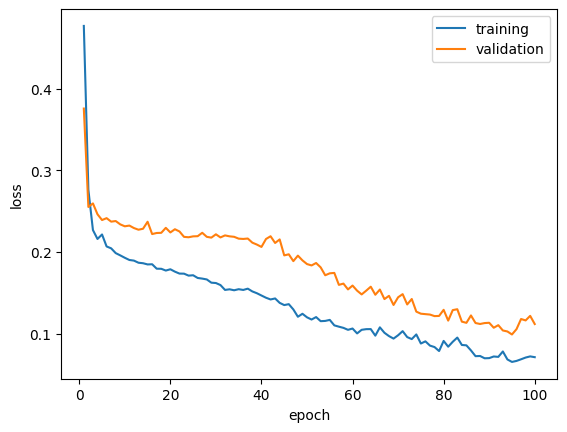

In [0]:
#plot the loss:
%matplotlib inline
from matplotlib import pyplot as plt

plt.plot(epoch_nums, training_loss)
plt.plot(epoch_nums, validation_loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training', 'validation'], loc='upper right')
plt.show()


**11. View Weights and Biases**<br>
The trained model consists of the final weights and biases that were determined by the optimizer during training. Based on our network model we should expect the following values for each layer:

- Layer 1 (fc1): There are five input values going to ten output nodes, so there should be 10 x 5 weights and 10 bias values.
- Layer 2 (fc2): There are ten input values going to ten output nodes, so there should be 10 x 10 weights and 10 bias values.
- Layer 3 (fc3): There are ten input values going to two output nodes, so there should be 2 x 10 weights and 2 bias values.



In [0]:
#  view the layers in your trained model:
for param_tensor in model.state_dict():
   print(param_tensor, "\n", model.state_dict()[param_tensor].cpu().numpy())

fc1.weight 
 [[-2.16125883e-03  1.54857919e-01 -2.37592667e-01 -2.12447301e-01
  -1.11184485e-01  7.74103627e-02 -5.71957231e-03  2.28887469e-01
  -2.56181993e-02  7.63870627e-02 -8.72413963e-02 -5.67435399e-02]
 [-1.92150211e+00 -1.62911820e+00 -5.63848019e-01 -1.95457518e-01
  -6.23618305e-01  7.67837286e-01 -5.10648675e-02 -3.26189905e-01
   2.45238572e-01  5.61873436e-01 -3.22384268e-01 -6.02159858e-01]
 [-4.65296283e-02  3.05458996e-02  2.61388451e-01 -2.67795354e-01
  -1.81731939e-01 -7.30825067e-02 -1.12525553e-01  2.49415547e-01
  -1.87113345e-01 -1.32886648e-01 -2.01680124e-01 -2.70361871e-01]
 [-2.65183896e-01  1.53527722e-01  3.26477736e-02  5.64446859e-02
  -9.00073797e-02 -2.46062115e-01 -5.67839965e-02 -3.49013031e-01
  -3.11416775e-01 -1.79900780e-01  7.17736855e-02  7.30593726e-02]
 [-1.97578907e-01 -1.61017086e-02  1.52584031e-01  2.10541844e-01
   4.98591959e-02 -2.49820072e-02  1.20800346e-01 -2.45295614e-01
  -2.36710142e-02 -2.23811418e-01 -2.00076729e-01 -1.491248


**12. Save the Trained Model**<br>
Now that we have a trained model, we can save its trained weights for later use.


In [0]:
# Save the model weights
model_file = '/Volumes/workspace/default/youtubeseries/diabetes_classifier.pt'
torch.save(model.state_dict(), model_file)
del model
print('model saved as', model_file)

model saved as /Volumes/workspace/default/youtubeseries/diabetes_classifier.pt
